In [30]:
import os
import requests
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from tqdm import tqdm

import geopandas as gpd
import contextily as ctx
from pyproj import Geod
from shapely.geometry import Point, LineString, Polygon

plt.rcParams['font.family'] = ['Arial', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

## 数据预处理

- 人口数据：[GHSL World Urbanisation Prospect 2025 data](https://human-settlement.emergency.copernicus.eu/GHSWUPDownload.php)

- urbanArea数据：[Mapping global urban boundaries from the global artificialimpervious area (GAIA) data](https://figshare.com/articles/dataset/Mapping_global_urban_boundaries_from_the_global_artificialimpervious_area_GAIA_data/32083476)

### 城市市政府驻地

In [2]:
data = {
    'city': [
        '北京市', '上海市', '天津市', '重庆市',
        '哈尔滨市', '长春市', '沈阳市', '大连市', '济南市', '青岛市',
        '南京市', '杭州市', '宁波市', '厦门市', '广州市', '深圳市',
        '武汉市', '成都市', '西安市',
        '石家庄市', '太原市', '郑州市', '长沙市', '合肥市', '福州市',
        '南昌市', '昆明市', '贵阳市', '南宁市', '海口市', '兰州市',
        '西宁市', '银川市', '乌鲁木齐市', '呼和浩特市', '拉萨市'
    ],                                              # 省会/首府
    'category': (
        ['直辖市'] * 4 +
        ['副省级市'] * 15 +
        ['省会'] * 17
    )
}
cities = pd.DataFrame(data)

In [3]:
cities.head(5)

,city,category
0,北京市,直辖市
1,上海市,直辖市
2,天津市,直辖市
3,重庆市,直辖市
4,哈尔滨市,副省级市


In [4]:
def GeoEncode(city, max_retries=3):
    
    params = {
        "address": f"{city}人民政府",
        "output": "json",
        "ak": os.getenv('BAIDU_GEOENCODE')
    }
    
    for attempt in range(max_retries):
        try:
            response = requests.get(
                url="https://api.map.baidu.com/geocoding/v3/", 
                params=params, 
                timeout=10
            )
            response.raise_for_status()
            
            result = response.json()
            
            # 检查百度API返回状态
            if result.get('status') == 0:
                location = result['result']['location']
                return location['lng'], location['lat']
            else:
                error_msg = result.get('msg', '未知错误')
                print(f"第{attempt+1}次调用失败: {error_msg}")
                
                # 如果是配额超限等严重错误，不再重试
                if result.get('status') in [2, 4, 5, 6]:
                    print(f"(status={result.get('status')})，停止重试")
                    break
                
        except requests.Timeout:
            print(f"第{attempt+1}次调用超时")
        except requests.ConnectionError:
            print(f"第{attempt+1}次调用网络连接失败")
        except (KeyError, ValueError) as e:
            print(f"第{attempt+1}次调用解析失败: {e}")
        except Exception as e:
            print(f"第{attempt+1}次调用未知异常: {e}")
        
        # 指数退避，第1次等0.5s，第2次等1s，第3次等2s
        if attempt < max_retries - 1:
            wait_time = 0.5 * (2 ** attempt)
    
    # 所有尝试都失败
    print(f"地址 '{city}' 地理编码最终失败")
    return 999, 999

In [5]:
tqdm.pandas()
cities[['lon', 'lat']] = cities['city'].progress_apply(
    lambda x: pd.Series(GeoEncode(x))
)

 44%|████▍     | 16/36 [00:05<00:08,  2.44it/s]

第1次调用失败: 未知错误


100%|██████████| 36/36 [00:12<00:00,  2.95it/s]


In [6]:
cities.to_csv("data/city_gov_coordinate.csv", index=False)

### 加载数据

In [2]:
urbanArea = gpd.read_file("data/GUB_China/GUB_2025.shp")
urbanArea

,urbanArea,city,geometry
0,2.169260,阜阳市,"POLYGON ((114.90117 33.10121, 114.90117 33.100..."
1,2.369113,阜阳市,"POLYGON ((114.90764 32.98533, 114.90764 32.988..."
2,2.369113,驻马店市,"MULTIPOLYGON (((114.92138 32.96161, 114.92138 ..."
3,4.462902,阜阳市,"POLYGON ((114.93809 33.08881, 114.93809 33.088..."
4,1.569496,阜阳市,"POLYGON ((114.98337 33.03977, 114.98337 33.039..."
...,...,...,...
15419,4.194440,上海市,"POLYGON ((121.71507 31.39639, 121.71507 31.396..."
15420,1.173710,上海市,"POLYGON ((121.62937 31.43331, 121.62937 31.433..."
15421,3.016030,上海市,"POLYGON ((121.6857 31.38264, 121.68516 31.3826..."
15422,3.229750,上海市,"POLYGON ((121.82314 31.36378, 121.82314 31.363..."


In [3]:
china = gpd.read_file(r"G:\台式机代码\2024\地级\T2024年初地级.shp")[["地名","geometry"]].rename(columns={"地名":"city"})
china

,city,geometry
0,阿克苏地区,"POLYGON ((83.41169 39.48265, 83.35937 39.48294..."
1,阿拉尔市,"POLYGON ((81.80661 40.80595, 81.80316 40.80076..."
2,阿拉善盟,"POLYGON ((99 42.60309, 99.50532 42.56749, 99.9..."
3,阿勒泰地区,"POLYGON ((90.67027 45.48714, 90.66637 45.48529..."
4,阿里地区,"POLYGON ((86.19145 31.00676, 86.1888 31.00496,..."
...,...,...
367,郑州市,"POLYGON ((113.88754 34.32784, 113.8875 34.3279..."
368,白杨市,"MULTIPOLYGON (((82.61266 46.30422, 82.61515 46..."
369,塔城地区,"POLYGON ((83.16719 47.22455, 83.1809 47.21941,..."
370,阿坝藏族羌族自治州,"POLYGON ((104.43382 33.3244, 104.43411 33.3238..."


In [4]:
pop = pd.read_csv("data/pop_2km.csv")
pop = pop[pop["pop"]>=1].reset_index(drop=True)
pop

,pop,lon,lat,city
0,3,123.623358,53.540096,大兴安岭地区
1,148,123.053670,53.500787,大兴安岭地区
2,17,123.081285,53.500787,大兴安岭地区
3,7,122.299788,53.481137,大兴安岭地区
4,46,122.327395,53.481137,大兴安岭地区
...,...,...,...,...
1002105,304,109.601282,18.193457,三亚市
1002106,47,109.574273,18.176962,三亚市
1002107,2,109.594870,18.176962,三亚市
1002108,6,109.615467,18.176962,三亚市


In [5]:
cities = pd.read_csv("data/city_gov_coordinate.csv")
cities

,city,category,lon,lat
0,北京市,直辖市,116.731059,39.910880
1,上海市,直辖市,121.480248,31.236276
2,天津市,直辖市,117.208087,39.091091
3,重庆市,直辖市,106.556901,29.570045
4,哈尔滨市,副省级市,126.541883,45.808610
5,长春市,副省级市,125.330253,43.822795
6,沈阳市,副省级市,123.471122,41.683657
7,大连市,副省级市,121.621314,38.919658
8,济南市,副省级市,117.126541,36.658400
9,青岛市,副省级市,120.389104,36.073007


## 制图

In [32]:
# 参考：https://transbigdata.readthedocs.io/zh-cn/latest/gallery/index.html
def plot_scale(ax, bounds, textcolor='k', textsize=8,
               length=None, scale_height=None, rect=[0.1, 0.1], unit="KM",
               style=1, **kwargs):
    """
    在地图上添加比例尺
    Parameters
    ----------
    ax : matplotlib axes
    bounds : list
        底图范围 [lon1, lat1, lon2, lat2]（WGS84）
    textcolor : str
        文字/边框颜色
    textsize : float
        文字大小
    length : float or None
        【核心】比例尺**总实地长度，单位米**。
        不管style分几段，整条比例尺代表的实地距离就是length；
        length=None 自动估算比例尺总长
    scale_height : float or None
        比例尺条**高度（地图坐标下的纬度跨度）**；
        None 自动按比例尺总长比例生成
    rect : list
        [a, c]，比例尺位置；[0,0] 左下，[1,1] 右上
    unit : str
        'KM' / 'km' / 'M' / 'm'
    style : int
        1 = 四段黑白相间；2 = 两段黑白
    """
    lon1, lat1, lon2, lat2 = bounds
    a, c = rect
    # 比例尺左下角坐标
    alon = lon1 + (lon2 - lon1) * a
    alat = lat1 + (lat2 - lat1) * c

    # 中心点纬度，计算1米对应的经度差(WGS84)
    mid_lat = (lat1 + lat2) * math.pi / 360
    lon_per_m = 360 / (2 * math.pi * 6371004 * math.cos(mid_lat))

    # 自动模式：自动估算总长
    if length is None:
        auto_base = int((lon2 - lon1) / 0.0003 / 1000 + 0.5) * 1000
        length = auto_base * 8

    # 整条比例尺对应的经度跨度
    total_dlon = length * lon_per_m
    # 高度
    if scale_height is None:
        scale_height = total_dlon * 0.12

    if style == 1:
        n_seg = 4
        seg_dlon = total_dlon / n_seg
        # 构造4个多边形
        color_list = [(0, 0, 0), (1, 1, 1), (0, 0, 0), (1, 1, 1)]
        geoms = []
        for i in range(n_seg):
            geoms.append(Polygon([
                (alon + i * seg_dlon, alat),
                (alon + (i + 1) * seg_dlon, alat),
                (alon + (i + 1) * seg_dlon, alat + scale_height),
                (alon + i * seg_dlon, alat + scale_height)
            ]))
        scale = gpd.GeoDataFrame({"color": color_list, "geometry": geoms})
        scale.plot(ax=ax, edgecolor=textcolor, facecolor=scale["color"], lw=0.6,**kwargs)
        # 刻度：0, 1/4, 2/4, 3/4, 1
        ticks_frac = [0, 0.25, 0.5, 0.75, 1.0]

    elif style == 2:
        n_seg = 2
        seg_dlon = total_dlon / n_seg
        color_list = [(0, 0, 0), (1, 1, 1)]
        geoms = []
        for i in range(n_seg):
            geoms.append(Polygon([
                (alon + i * seg_dlon, alat),
                (alon + (i + 1) * seg_dlon, alat),
                (alon + (i + 1) * seg_dlon, alat + scale_height),
                (alon + i * seg_dlon, alat + scale_height)
            ]))
        scale = gpd.GeoDataFrame({"color": color_list, "geometry": geoms})
        scale.plot(ax=ax, edgecolor=textcolor, facecolor=scale["color"], lw=0.6,**kwargs)
        # 刻度：0, 0.5, 1
        ticks_frac = [0, 0.5, 1.0]
    else:
        return

    # 批量绘制刻度文字
    for frac in ticks_frac:
        dist_m = frac * length
        if unit.upper() == "KM":
            val = dist_m / 1000
        else:
            val = dist_m
        ax.text(alon + frac * total_dlon, alat + scale_height * 1.2,
                f"{val:.0f}", color=textcolor, fontsize=textsize, ha="center", va="bottom")
    # 单位标注
    ax.text(alon + total_dlon * 1 + 0.015, alat + scale_height * 0, unit,
            color=textcolor, fontsize=textsize+2, ha="left")


def plot_compass(ax, bounds, textcolor='k', textsize=8,
                 compasssize=1.0, rect=[0.9, 0.9], **kwargs):
    """
    在地图上添加指北针
    Parameters
    ----------
    ax : matplotlib axes
    bounds : list
        底图范围 [lon1, lat1, lon2, lat2]（WGS84）
    textcolor : str
        'N' 字与边框颜色
    textsize : float
        'N' 字大小
    compasssize : float
        指北针大小（相对地图宽度的比例，默认 1.0 → 约 3% 地图宽）
    rect : list
        [a, c]，指北针位置；[0,0] 左下，[1,1] 右上
        这里指的是"箭头底部"锚点位置
    """
    lon1, lat1, lon2, lat2 = bounds
    deltaLon = (lon2 - lon1) * 0.03 * compasssize
    a, c = rect
    alon = lon1 + (lon2 - lon1) * a
    alat = lat1 + (lat2 - lat1) * c

    compass = gpd.GeoDataFrame({
        'color': [(0, 0, 0), (1, 1, 1)],
        'geometry': [
            Polygon([[alon, alat],
                     [alon, alat + deltaLon],
                     [alon + 0.5 * deltaLon, alat - 0.5 * deltaLon]]),
            Polygon([[alon, alat],
                     [alon, alat + deltaLon],
                     [alon - 0.5 * deltaLon, alat - 0.5 * deltaLon]])
        ]})
    compass.plot(ax=ax, edgecolor=textcolor,
                 facecolor=compass['color'], lw=0.6, **kwargs)
    ax.text(alon, alat + deltaLon, 'N',
            color=textcolor, fontsize=textsize,
            ha='center', va='bottom')


geod = Geod(ellps="WGS84")
def geodesic_area(geom):
    # geometry_area_perimeter 返回 (面积, 周长)
    area, _ = geod.geometry_area_perimeter(geom)
    return abs(area) / 1e6

### 单张测试

In [7]:
demo = urbanArea[urbanArea["city"]=="上海市"]
demo.head(5)

,urbanArea,city,geometry
8961,15.585797,上海市,"MULTIPOLYGON (((120.8694 31.1304, 120.86934 31..."
12807,5.755686,上海市,"POLYGON ((120.90713 31.07731, 120.90713 31.077..."
12808,4.106561,上海市,"POLYGON ((120.92761 31.13902, 120.92761 31.138..."
12809,5.648463,上海市,"POLYGON ((120.96453 31.08863, 120.96453 31.088..."
12811,25.479471,上海市,"POLYGON ((120.99552 30.9237, 120.99552 30.9239..."


In [8]:
# GRID = 0.05
# pop["grid_lon"] = np.floor(pop["lon"] / GRID).astype(int)
# pop["grid_lat"] = np.floor(pop["lat"] / GRID).astype(int)

# grid = (
#     pop.groupby(["city", "grid_lon", "grid_lat"], as_index=False)["pop"]
#        .sum()
# )
# grid["lon"] = (grid["grid_lon"] + 0.5) * GRID
# grid["lat"] = (grid["grid_lat"] + 0.5) * GRID
# grid = grid[["city", "lon", "lat", "pop"]].sort_values(
#     ["city", "lat", "lon"]
# ).reset_index(drop=True)

In [8]:
demo1 = pop[pop["city"]=="上海市"]
# demo1 = grid[grid["city"]=="上海市"]
demo1.head(5)

,pop,lon,lat,city
541420,7,121.267007,31.861815,上海市
541421,5,121.289088,31.861815,上海市
541422,6,121.311168,31.861815,上海市
542131,359,121.230844,31.844603,上海市
542132,1040,121.252922,31.844603,上海市


In [9]:
C_LAND = "#D9D9D9"
C_LAND_EDGE = "#FFFFFF"
C_LINE = "#30363B"
C_ACCENT = "#3C7187"
C_TEXT = "#202326"
C_FAINT = "#858B90"

COLORS = [
    "#F7F3E9",
    "#F2E2C4",
    "#EFC78F",
    "#E9A05E",
    "#D96B43",
    "#B83B35",
    "#8F2635",
    "#5B1725",
]
cmap_pop = LinearSegmentedColormap.from_list(
    "population",
    COLORS,
    N=256
)

d:\Anaconda3\envs\py311\Lib\site-packages\geopandas\geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
C:\Users\15499\AppData\Local\Temp\ipykernel_3644\2044118334.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffer_ = gov.buffer(1)
C:\Users\15499\AppData\Local\Temp\ipykernel_3644\2044118334.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


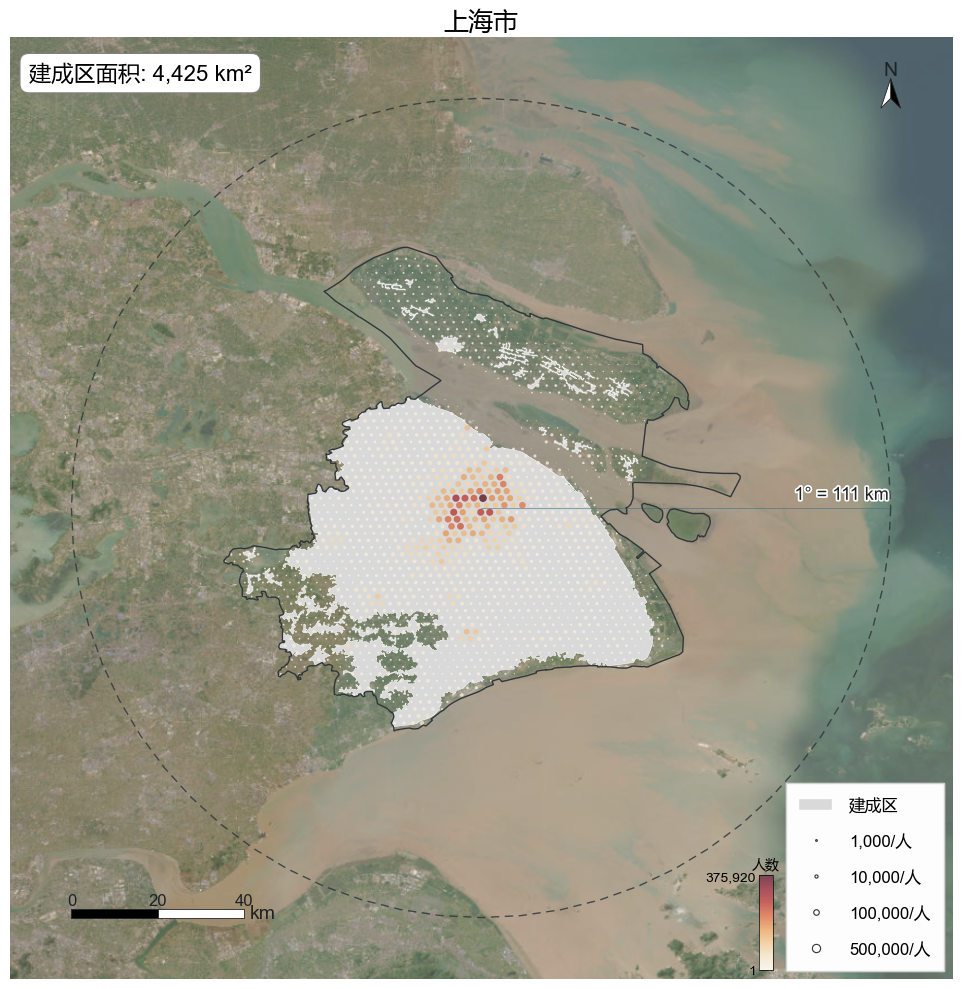

In [44]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_aspect('equal')

city_name = "上海市"
china[china["city"]==city_name].boundary.plot(
    ax=ax,
    linewidth=1,
    edgecolor=C_LINE,
    zorder=4
)
#urbanArea
urbanArea_ = urbanArea[urbanArea["city"]==city_name]
urbanArea_['area_km2'] = urbanArea_.geometry.apply(geodesic_area)
urbanArea_.plot(
    ax=ax,
    color=C_LAND,
    edgecolor=C_LAND_EDGE,
    linewidth=0.3,
    alpha=1,
    zorder=1,
)
# 标注面积
total_km2 = urbanArea_['area_km2'].sum()
text = f"建成区面积: {total_km2:,.0f} km²"
ax.text(
    0.02, 0.95,
    text,
    transform=ax.transAxes, # 用相对坐标，不随地图范围变化
    fontsize=16,
    color="black",
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        linewidth=0.8,
        alpha=1,
    ),
    zorder=10,
)
# 人口分布
pop_ = pop[pop["city"] == city_name].copy()
vmin = pop_["pop"].min()
vmax = pop_["pop"].max()
norm = Normalize(vmin=vmin, vmax=vmax)
pop_["point_size"] = np.sqrt(pop_["pop"]) / 20
pop_ax = ax.scatter(
    pop_["lon"],
    pop_["lat"],
    c=pop_["pop"],
    cmap=cmap_pop,
    norm=norm,
    s=pop_["point_size"],
    alpha=0.80,
    linewidths=0,
    zorder=3,
)

# 市政府
city_ = cities[cities["city"]==city_name].reset_index(drop=True)
gov_point = Point(city_.loc[0,"lon"], city_.loc[0,"lat"])
gov = gpd.GeoSeries([gov_point], crs="EPSG:4326")

# 1° 缓冲区
buffer_ = gov.buffer(1)
buffer_.plot(
    ax=ax,
    facecolor='none',
    edgecolor=C_LINE,
    linewidth=1.0,
    linestyle=(0, (6, 4)),   # 6pt 实 + 4pt 空
    alpha=0.85,
    zorder=5,
)

# 径线
radius_line = gpd.GeoSeries(
    [LineString([(gov_point.x, gov_point.y),
                 (gov_point.x + 1, gov_point.y)])],
    crs="EPSG:4326"
)
radius_line.plot(
    ax=ax,
    facecolor='none',
    edgecolor=C_ACCENT,
    linewidth=0.4,
    linestyle='-',
    alpha=1,
    zorder=2,
)

# # 市政府点
# gov_geo = gpd.GeoSeries([gov_point], crs="EPSG:4326").to_crs(demo.crs)
# gov_geo.plot(
#     ax=ax,
#     color=C_ACCENT,
#     markersize=140,
#     marker='*',
#     edgecolor='white',
#     linewidth=0.8,
#     zorder=6,
# )

# 标注半径
mid_x = gov_point.x + 0.88
mid_y = gov_point.y
ax.text(
    mid_x, mid_y + 0.01,
    '1° = 111 km',
    ha='center', va='bottom',
    fontsize=13,
    fontweight='medium',
    color=C_TEXT,
    zorder=7,
    path_effects=[
        # 白描边让文字在灰底/彩底上都可读
        __import__('matplotlib.patheffects', fromlist=['withStroke']).withStroke(
            linewidth=2.5, foreground='white')
    ],
)

# 影像
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    crs="EPSG:4326",
    alpha=0.75,
    # zoom=10,
    attribution=False,
    zorder=0,
)

# 图例
# 人口
legend_values = [1_000, 10_000, 100_000, 500_000]
legend_sizes = np.sqrt(legend_values) / 20
population_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor="white",
        markeredgecolor=C_LINE,
        markeredgewidth=0.8,
        markersize=np.sqrt(size),
    )
    for size in legend_sizes
]
population_labels = [
    f"{value:,}/人"
    for value in legend_values
]
#urbanArea
urban_handle = Patch(
    facecolor=C_LAND,
    edgecolor=C_LAND_EDGE,
    linewidth=0.3,
    alpha=1,
)
handles = [
    urban_handle,
    *population_handles,
]
labels = [
    "建成区",
    *population_labels,
]
legend = ax.legend(
    handles,
    labels,
    title="",
    loc="lower right",
    frameon=True,
    fancybox=False,
    framealpha=0.90,
    edgecolor="#D0D0D0",
    facecolor="white",
    fontsize=12,
    title_fontsize=14,
    handletextpad=1.0,
    labelspacing=1.2,
    borderpad=0.8,
)
ax.add_artist(legend)

# cbar
cax = inset_axes(
    ax,
    width="1.5%",
    height="10%",
    loc="lower right",
    bbox_to_anchor=(-0.19, 0.01, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
cbar = fig.colorbar(
    pop_ax,
    cax=cax,
    orientation="vertical",
)
cbar.set_ticks([vmin, vmax])  # 只显示 min / max
cbar.set_ticklabels([ # 标签格式
    f"{vmin:,.0f}",
    f"{vmax:,.0f}",
])
cbar.ax.yaxis.set_ticks_position("left")  # 刻度线在左侧
cbar.ax.yaxis.set_label_position("left")
cbar.ax.tick_params(  # 刻度文字
    labelsize=10,
    length=0,  # 不显示小刻度线
    pad=2,
)
cbar.ax.set_title("人数", fontsize=10, pad=5)
cbar.outline.set_linewidth(0.5)


# 比例尺指北针
bounds = buffer_.total_bounds.tolist()
plot_scale(
    ax, bounds,
    style=2, unit='km',
    rect=[0.0, 0.0],
    textsize=12,
    length=40000,
    scale_height=0.02,
    textcolor=C_TEXT,
)
plot_compass(
    ax, bounds,
    compasssize=0.8,
    textsize=14,
    rect=[1, 1],
    textcolor=C_TEXT,
)

# 去边框
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_facecolor('white')

# 显示范围
pad_x = (bounds[2] - bounds[0]) * 0.075
pad_y = (bounds[3] - bounds[1]) * 0.075
ax.set_xlim(bounds[0] - pad_x, bounds[2] + pad_x)
ax.set_ylim(bounds[1] - pad_y, bounds[3] + pad_y)
ax.set_title(city_name, fontsize=18)


plt.tight_layout()
plt.show()

### 批处理

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [50]:
def draw_(city_name, save=None):

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_aspect('equal')

    china[china["city"]==city_name].boundary.plot(
        ax=ax,
        linewidth=1,
        edgecolor=C_LINE,
        zorder=4
    )
    #urbanArea
    urbanArea_ = urbanArea[urbanArea["city"]==city_name]
    urbanArea_['area_km2'] = urbanArea_.geometry.apply(geodesic_area)
    urbanArea_.plot(
        ax=ax,
        color=C_LAND,
        edgecolor=C_LAND_EDGE,
        linewidth=0.3,
        alpha=1,
        zorder=1,
    )
    # 标注面积
    total_km2 = urbanArea_['area_km2'].sum()
    text = f"建成区面积: {total_km2:,.0f} km²"
    ax.text(
        0.02, 0.95,
        text,
        transform=ax.transAxes, # 用相对坐标，不随地图范围变化
        fontsize=16,
        color="black",
        ha="left",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="gray",
            linewidth=0.8,
            alpha=1,
        ),
        zorder=10,
    )
    # 人口分布
    pop_ = pop[pop["city"] == city_name].copy()
    vmin = pop_["pop"].min()
    vmax = pop_["pop"].max()
    norm = Normalize(vmin=vmin, vmax=vmax)
    pop_["point_size"] = np.sqrt(pop_["pop"]) / 20
    pop_ax = ax.scatter(
        pop_["lon"],
        pop_["lat"],
        c=pop_["pop"],
        cmap=cmap_pop,
        norm=norm,
        s=pop_["point_size"],
        alpha=0.80,
        linewidths=0,
        zorder=3,
    )

    # 市政府
    city_ = cities[cities["city"]==city_name].reset_index(drop=True)
    gov_point = Point(city_.loc[0,"lon"], city_.loc[0,"lat"])
    gov = gpd.GeoSeries([gov_point], crs="EPSG:4326")

    # 1° 缓冲区
    buffer_ = gov.buffer(1)
    buffer_.plot(
        ax=ax,
        facecolor='none',
        edgecolor=C_LINE,
        linewidth=1.0,
        linestyle=(0, (6, 4)),   # 6pt 实 + 4pt 空
        alpha=0.85,
        zorder=5,
    )

    # 径线
    radius_line = gpd.GeoSeries(
        [LineString([(gov_point.x, gov_point.y),
                    (gov_point.x + 1, gov_point.y)])],
        crs="EPSG:4326"
    )
    radius_line.plot(
        ax=ax,
        facecolor='none',
        edgecolor=C_ACCENT,
        linewidth=0.4,
        linestyle='-',
        alpha=1,
        zorder=2,
    )

    # 标注半径
    mid_x = gov_point.x + 0.88
    mid_y = gov_point.y
    ax.text(
        mid_x, mid_y + 0.01,
        '1° = 111 km',
        ha='center', va='bottom',
        fontsize=13,
        fontweight='medium',
        color=C_TEXT,
        zorder=7,
        path_effects=[
            # 白描边让文字在灰底/彩底上都可读
            __import__('matplotlib.patheffects', fromlist=['withStroke']).withStroke(
                linewidth=2.5, foreground='white')
        ],
    )

    # 影像
    ctx.add_basemap(
        ax,
        source=ctx.providers.Esri.WorldImagery,
        crs="EPSG:4326",
        alpha=0.75,
        attribution=False,
        zorder=0,
    )

    # 图例
    # 人口
    legend_values = [1_000, 10_000, 100_000, 500_000]
    legend_sizes = np.sqrt(legend_values) / 20
    population_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            markerfacecolor="white",
            markeredgecolor=C_LINE,
            markeredgewidth=0.8,
            markersize=np.sqrt(size),
        )
        for size in legend_sizes
    ]
    population_labels = [
        f"{value:,}/人"
        for value in legend_values
    ]
    #urbanArea
    urban_handle = Patch(
        facecolor=C_LAND,
        edgecolor=C_LAND_EDGE,
        linewidth=0.3,
        alpha=1,
    )
    handles = [
        urban_handle,
        *population_handles,
    ]
    labels = [
        "建成区",
        *population_labels,
    ]
    legend = ax.legend(
        handles,
        labels,
        title="",
        loc="lower right",
        frameon=True,
        fancybox=False,
        framealpha=0.90,
        edgecolor="#D0D0D0",
        facecolor="white",
        fontsize=12,
        title_fontsize=14,
        handletextpad=1.0,
        labelspacing=1.2,
        borderpad=0.8,
    )
    ax.add_artist(legend)

    # cbar
    cax = inset_axes(
        ax,
        width="1.5%",
        height="10%",
        loc="lower right",
        bbox_to_anchor=(-0.19, 0.01, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    cbar = fig.colorbar(
        pop_ax,
        cax=cax,
        orientation="vertical",
    )
    cbar.set_ticks([vmin, vmax])  # 只显示 min / max
    cbar.set_ticklabels([ # 标签格式
        f"{vmin:,.0f}",
        f"{vmax:,.0f}",
    ])
    cbar.ax.yaxis.set_ticks_position("left")  # 刻度线在左侧
    cbar.ax.yaxis.set_label_position("left")
    cbar.ax.tick_params(  # 刻度文字
        labelsize=10,
        length=0,  # 不显示小刻度线
        pad=2,
    )
    cbar.ax.set_title("人数", fontsize=10, pad=5)
    cbar.outline.set_linewidth(0.5)


    # 比例尺指北针
    bounds = buffer_.total_bounds.tolist()
    plot_scale(
        ax, bounds,
        style=2, unit='km',
        rect=[0.0, 0.0],
        textsize=12,
        length=40000,
        scale_height=0.02,
        textcolor=C_TEXT,
    )
    plot_compass(
        ax, bounds,
        compasssize=0.8,
        textsize=14,
        rect=[1, 1],
        textcolor=C_TEXT,
    )

    # 去边框
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor('white')

    # 显示范围
    pad_x = (bounds[2] - bounds[0]) * 0.075
    pad_y = (bounds[3] - bounds[1]) * 0.075
    ax.set_xlim(bounds[0] - pad_x, bounds[2] + pad_x)
    ax.set_ylim(bounds[1] - pad_y, bounds[3] + pad_y)
    ax.set_title(city_name, fontsize=18)


    plt.tight_layout()
    if save:
        plt.savefig(f"fig/{city_name}.png", dpi=300, bbox_inches='tight')
    # plt.show()

In [51]:
figs = os.listdir("fig")
figs = [name.split(".")[0] for name in figs]
figs

[]

In [ ]:
for city_name in cities["city"].unique():
    if city_name not in figs:
        print(f"绘制 {city_name}")
        draw_(city_name, save=True)